# AAV2 -- ShallowProfileMLP plus débruiteur sur `viab` (poids invvar + filtre profondeur)

Suite à `AAV2_viab_noise_ceiling.ipynb` (plafond de bruit) et à la note technique
`Modelization_V2/docs/NGS_noise_ceiling_reliability.tex` : on a maintenant un poids par
variant, `w = 1/Var(bruit)`, censé quantifier combien chaque mesure est fiable. Idée testée
ici : **l'utiliser réellement comme signal d'entraînement** (loss MSE pondérée), pas
seulement pour calculer un plafond -- et le combiner avec un filtre de profondeur de comptage
(`compte_plasmide`), la seconde piste identifiée dans la même discussion.

Deux leviers, testés en **plan 2x2** (population x loss) sur la même architecture
(`ShallowProfileMLP`, ~27k params, reprise verbatim d'`AAV2_viab_profile_model.ipynb`) :

1. **Pondération inverse-variance winsorisée** -- `w = 1/(1/(virus+eps)+1/(plasmide+eps))`
   (même formule que la régression de Potts), **plafonnée au p99** avant normalisation. Cette
   idée a déjà été testée SANS plafonnement sur AAV5 `sel_org2`
   (`AAV5_SEL_profile_model_sel_org2_invvar.ipynb`, notebook depuis supprimé) et avait dégradé
   `r` partout -- diagnostic : la moyenne de normalisation était dominée par quelques poids
   extrêmes issus de comptages de contamination. Le plafonnement au p99 est le correctif
   proposé mais jamais testé.
2. **Filtre de profondeur** -- restreindre à `compte_plasmide >= 10` en plus du filtre `viab`
   déjà en place (`AAV2_organoides_sorted.csv`, `PLASMID_MIN=1`+`RATIO_MAX=100`). Seuil informé
   par le sweep de `AAV2_viab_noise_ceiling.ipynb` §5 (plafond de corrélation vs seuil
   `compte_plasmide`) et par le `PLASMID_MIN_GRID` déjà balayé dans `AAV2_viab_sorting.ipynb`.

Références déjà validées pour situer les résultats : régression de Potts CV sur ce même CSV
`trié`, held-out r=+0.266 (`AAV2_viab_sorting.ipynb` §9) ; sur la population top-10 000 par
`compte_plasmide` (différente de celle testée ici), Potts CV r=+0.252, ProfileMLP r=+0.274
(`AAV2_viab_top10k_potts_protocol_mlp.ipynb`).

Hors périmètre (décidé en session) : loss Poisson/Multinomial -- uniquement pondération MSE +
filtrage ici. Pas de dithering (feedback : "ajoute juste du bruit").

**Pas exécuté automatiquement** -- entraînement JAX/GPU, laissé pour que tu le lances toi-même
(4 entraînements ShallowProfileMLP, quelques minutes chacun selon le volume retenu).


In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split

_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if p.name == "Modelization_V2")
sys.path.insert(0, str(_root / "lib"))
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

import jax
import jax.numpy as jnp
from flax import nnx
from typing import Optional
import optax
from tqdm.auto import tqdm

from analysisV1 import AA_LABELS, pearson, precision_at_k, plot_topk_recovery

print(f"JAX backend: {jax.default_backend()} -- devices: {jax.devices()}")

L, A = 7, 20

CSV = Path("AAV2_organoides_sorted.csv")
if not CSV.exists():
    CSV = _root / "notebooks/notebooks/Selectivity/AAV2/AAV2_organoides_sorted.csv"
assert CSV.exists(), CSV

VIAB_COL = "log2_enrichissement_virus_sur_plasmide"
use_cols = ["sequence", "compte_plasmide", "compte_virus", VIAB_COL]
dtypes = {"sequence": "string", "compte_plasmide": "float32", "compte_virus": "float32", VIAB_COL: "float32"}
df = pd.read_csv(CSV, usecols=use_cols, dtype=dtypes)
df["sequence"] = df["sequence"].astype("string")
print(f"{len(df):,} lignes chargées depuis {CSV.name}")

plasmid = df["compte_plasmide"].to_numpy(np.float64)
virus   = df["compte_virus"].to_numpy(np.float64)
y_all   = df[VIAB_COL].to_numpy(np.float64)

lut = np.zeros(256, dtype=np.int64)
for i, aa in enumerate(AA_LABELS):
    lut[ord(aa)] = i
S = lut[np.frombuffer("".join(df["sequence"]).encode("ascii"), np.uint8)].reshape(len(df), L)


/home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


JAX backend: gpu -- devices: [CudaDevice(id=0)]
2,746,425 lignes chargées depuis AAV2_organoides_sorted.csv


### 1. Poids inverse-variance winsorisé

`eps=0.5` (convention projet). Plafonné au p99 AVANT normalisation -- le correctif jamais testé sur l'échec AAV5 `sel_org2`.

In [2]:
EPS = 0.5
w_raw = 1.0 / (1.0 / (virus + EPS) + 1.0 / (plasmid + EPS))

pcts = [0, 50, 90, 99, 99.9, 100]
print("percentiles w_raw (avant plafonnement) :")
for p in pcts:
    print(f"  p{p:<5} = {np.percentile(w_raw, p):,.1f}")

W_CAP = np.percentile(w_raw, 99)
w_all = np.minimum(w_raw, W_CAP)
w_all = w_all / w_all.mean()   # normalise a moyenne 1 -- loss pondérée sur une échelle comparable a la MSE non pondérée

print(f"\nplafond p99 = {W_CAP:,.1f}  -- {int((w_raw > W_CAP).sum()):,} lignes plafonnées "
      f"({(w_raw > W_CAP).mean():.2%})")
print(f"poids normalisé, moyenne={w_all.mean():.3f}  (par construction) ; "
      f"max={w_all.max():.2f}  (avant plafonnement le max aurait été {w_raw.max()/w_raw.mean() if w_raw.mean()>0 else float('nan'):.1f}x plus haut)")


percentiles w_raw (avant plafonnement) :
  p0     = 0.8
  p50    = 1.4
  p90    = 3.5
  p99    = 7.6
  p99.9  = 13.3
  p100   = 44.4

plafond p99 = 7.6  -- 27,444 lignes plafonnées (1.00%)
poids normalisé, moyenne=1.000  (par construction) ; max=4.02  (avant plafonnement le max aurait été 23.2x plus haut)


### 2. Architecture -- ShallowProfileMLP (archi standard du projet, reprise verbatim)

In [3]:
class ShallowProfileMLP(nnx.Module):
    '''Archi standard du projet (Linear+BatchNorm+Dropout+GELU x2, ~27k params).'''

    def __init__(self, input_dim: int, hidden_dims: tuple[int, int] = (128, 64),
                 dropout_rate: float = 0.1, *, rngs: nnx.Rngs):
        h1, h2 = hidden_dims
        self.linear1    = nnx.Linear(input_dim, h1, rngs=rngs)
        self.batchnorm1 = nnx.BatchNorm(h1, use_running_average=False, rngs=rngs)
        self.dropout1   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear2    = nnx.Linear(h1, h2, rngs=rngs)
        self.batchnorm2 = nnx.BatchNorm(h2, use_running_average=False, rngs=rngs)
        self.dropout2   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear3    = nnx.Linear(h2, 1, rngs=rngs)

    def __call__(self, x: jax.Array, *, train: bool, rngs: Optional[nnx.Rngs] = None) -> jax.Array:
        x = self.linear1(x)
        x = self.batchnorm1(x, use_running_average=not train)
        x = self.dropout1(x, deterministic=not train, rngs=rngs)
        x = nnx.gelu(x)
        x = self.linear2(x)
        x = self.batchnorm2(x, use_running_average=not train)
        x = self.dropout2(x, deterministic=not train, rngs=rngs)
        x = nnx.gelu(x)
        return self.linear3(x).squeeze(-1)


_n_shallow = sum(p.size for p in jax.tree.leaves(nnx.state(ShallowProfileMLP(input_dim=L * A, rngs=nnx.Rngs(0)), nnx.Param)))
print(f"ShallowProfileMLP: {_n_shallow:,} params")


ShallowProfileMLP: 26,753 params


### 3. Boucles d'entraînement -- non pondérée (verbatim AAV5/AAV2) + pondérée (nouvelle)

La variante pondérée modifie UNIQUEMENT la loss d'entraînement (`sum(w*sqerr)/sum(w)` au lieu de `mean(sqerr)`). L'early stopping reste sur la MSE **non pondérée** de validation dans les deux cas -- même critère de généralisation pour une comparaison honnête ; seul ce que le modèle optimise pendant l'entraînement change.

In [4]:
@nnx.jit
def train_step(model, optimizer, x, y, rngs):
    def loss_fn(model, rngs):
        y_pred = model(x, train=True, rngs=rngs)
        return jnp.mean((y_pred - y) ** 2)
    loss, grads = nnx.value_and_grad(loss_fn)(model, rngs)
    optimizer.update(model, grads)
    return loss


@nnx.jit
def eval_step(model, x, y):
    y_pred = model(x, train=False)
    return jnp.mean((y_pred - y) ** 2)


@nnx.jit
def predict_step(model, x):
    return model(x, train=False)


@nnx.scan(in_axes=(nnx.Carry, 0, 0), out_axes=(nnx.Carry, 0))
def train_epoch_scan(carry, xb, yb):
    model, optimizer, rngs = carry
    loss = train_step(model, optimizer, xb, yb, rngs)
    return (model, optimizer, rngs), loss


def split_train_val(X, y, val_frac=0.15, seed=0):
    rng   = np.random.default_rng(seed)
    idx   = rng.permutation(len(X))
    n_val = int(len(X) * val_frac)
    val_idx, train_idx = idx[:n_val], idx[n_val:]
    return X[train_idx], y[train_idx], X[val_idx], y[val_idx]


def train_mlp(model_cls, model_kwargs, X_train, y_train, X_val, y_val,
              epochs=150, batch_size=512, peak_lr=1e-3, final_lr=1e-5,
              weight_decay=0, patience=5, seed=0, verbose=True):
    rngs  = nnx.Rngs(seed)
    model = model_cls(rngs=rngs, **model_kwargs)

    n_train         = X_train.shape[0]
    steps_per_epoch = max(n_train // batch_size, 1)
    total_steps     = steps_per_epoch * epochs

    lr_schedule_fn = optax.warmup_cosine_decay_schedule(
        init_value=0., peak_value=peak_lr,
        warmup_steps=int(total_steps * 0.1),
        decay_steps=int(total_steps * 0.9),
        end_value=final_lr,
    )
    optimizer = nnx.Optimizer(
        model, optax.adamw(learning_rate=lr_schedule_fn, weight_decay=weight_decay), wrt=nnx.Param
    )

    X_train, y_train = jnp.asarray(X_train), jnp.asarray(y_train)
    X_val,   y_val   = jnp.asarray(X_val),   jnp.asarray(y_val)

    shuffle_key = jax.random.key(seed)
    best_val, best_state, bad_epochs = float("inf"), None, 0
    history = {"train_loss": [], "val_loss": []}

    for epoch in tqdm(range(epochs), desc="  epochs", disable=not verbose, leave=False):
        shuffle_key, perm_key = jax.random.split(shuffle_key)
        perm      = jax.random.permutation(perm_key, n_train)
        batch_idx = perm[: steps_per_epoch * batch_size].reshape(steps_per_epoch, batch_size)

        (model, optimizer, rngs), step_losses = train_epoch_scan(
            (model, optimizer, rngs), X_train[batch_idx], y_train[batch_idx]
        )
        train_loss = float(jnp.mean(step_losses))
        val_loss   = float(eval_step(model, X_val, y_val))
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val - 1e-5:
            best_val, bad_epochs = val_loss, 0
            best_state = nnx.state(model)
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                break

    nnx.update(model, best_state)
    return model, history


def batched_predict(model, X_oh, batch_size=16384):
    chunks = []
    for start in range(0, X_oh.shape[0], batch_size):
        chunks.append(np.asarray(predict_step(model, jnp.asarray(X_oh[start:start + batch_size]))))
    return np.concatenate(chunks)


In [5]:
# --- variante ponderee : seule la loss d'entrainement change ---
@nnx.jit
def train_step_w(model, optimizer, x, y, w, rngs):
    def loss_fn(model, rngs):
        y_pred = model(x, train=True, rngs=rngs)
        se = (y_pred - y) ** 2
        return jnp.sum(w * se) / jnp.sum(w)
    loss, grads = nnx.value_and_grad(loss_fn)(model, rngs)
    optimizer.update(model, grads)
    return loss


@nnx.scan(in_axes=(nnx.Carry, 0, 0, 0), out_axes=(nnx.Carry, 0))
def train_epoch_scan_w(carry, xb, yb, wb):
    model, optimizer, rngs = carry
    loss = train_step_w(model, optimizer, xb, yb, wb, rngs)
    return (model, optimizer, rngs), loss


def split_train_val_w(X, y, w, val_frac=0.15, seed=0):
    # meme permutation/seed que split_train_val -> split train/val IDENTIQUE aux deux variantes
    rng   = np.random.default_rng(seed)
    idx   = rng.permutation(len(X))
    n_val = int(len(X) * val_frac)
    val_idx, train_idx = idx[:n_val], idx[n_val:]
    return X[train_idx], y[train_idx], w[train_idx], X[val_idx], y[val_idx]


def train_mlp_w(model_cls, model_kwargs, X_train, y_train, w_train, X_val, y_val,
                 epochs=150, batch_size=512, peak_lr=1e-3, final_lr=1e-5,
                 weight_decay=0, patience=5, seed=0, verbose=True):
    rngs  = nnx.Rngs(seed)
    model = model_cls(rngs=rngs, **model_kwargs)

    n_train         = X_train.shape[0]
    steps_per_epoch = max(n_train // batch_size, 1)
    total_steps     = steps_per_epoch * epochs

    lr_schedule_fn = optax.warmup_cosine_decay_schedule(
        init_value=0., peak_value=peak_lr,
        warmup_steps=int(total_steps * 0.1),
        decay_steps=int(total_steps * 0.9),
        end_value=final_lr,
    )
    optimizer = nnx.Optimizer(
        model, optax.adamw(learning_rate=lr_schedule_fn, weight_decay=weight_decay), wrt=nnx.Param
    )

    X_train, y_train, w_train = jnp.asarray(X_train), jnp.asarray(y_train), jnp.asarray(w_train)
    X_val,   y_val            = jnp.asarray(X_val),   jnp.asarray(y_val)

    shuffle_key = jax.random.key(seed)
    best_val, best_state, bad_epochs = float("inf"), None, 0
    history = {"train_loss": [], "val_loss": []}

    for epoch in tqdm(range(epochs), desc="  epochs", disable=not verbose, leave=False):
        shuffle_key, perm_key = jax.random.split(shuffle_key)
        perm      = jax.random.permutation(perm_key, n_train)
        batch_idx = perm[: steps_per_epoch * batch_size].reshape(steps_per_epoch, batch_size)

        (model, optimizer, rngs), step_losses = train_epoch_scan_w(
            (model, optimizer, rngs), X_train[batch_idx], y_train[batch_idx], w_train[batch_idx]
        )
        train_loss = float(jnp.mean(step_losses))
        val_loss   = float(eval_step(model, X_val, y_val))   # non pondere -- meme critere que la variante non ponderee
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val - 1e-5:
            best_val, bad_epochs = val_loss, 0
            best_state = nnx.state(model)
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                break

    nnx.update(model, best_state)
    return model, history


### 4. Plan 2x2 -- population (trié / trié+profondeur) x loss (non pondérée / pondérée)

`N_CAP` plafonne le volume fit+eval par population (comme les notebooks soeurs) -- adapte automatiquement si la population filtrée a moins de lignes disponibles. Même split fit/eval et même split train/val (seed=0) réutilisé pour les 2 modes de loss d'une même population : la seule variable qui change est la loss.

In [6]:
FILTER_PLASMID_MIN = 10
N_CAP = 300_000

populations = {
    "trié":                                   np.ones(len(df), dtype=bool),
    f"trié + plasmide>={FILTER_PLASMID_MIN}":  plasmid >= FILTER_PLASMID_MIN,
}

RNG = np.random.default_rng(0)
oh = lambda idx: np.eye(A, dtype=np.float32)[S[idx]].reshape(len(idx), -1)

results = {}
for pop_tag, pop_mask in populations.items():
    idx_finite = np.flatnonzero(np.isfinite(y_all) & pop_mask)
    if len(idx_finite) > N_CAP:
        idx_finite = RNG.choice(idx_finite, N_CAP, replace=False)
    fit_i, eval_i = train_test_split(idx_finite, test_size=0.5, random_state=0)

    X_fit,  y_fit,  w_fit = oh(fit_i),  y_all[fit_i],  w_all[fit_i]
    X_eval, y_eval         = oh(eval_i), y_all[eval_i]

    Xtr,   ytr,        Xva,   yva   = split_train_val(X_fit, y_fit, val_frac=0.15, seed=0)
    Xtr_w, ytr_w, wtr, Xva_w, yva_w = split_train_val_w(X_fit, y_fit, w_fit, val_frac=0.15, seed=0)
    assert np.array_equal(Xtr, Xtr_w) and np.array_equal(Xva, Xva_w), "les 2 splits doivent coincider"

    print(f"[{pop_tag}]  n_fit={len(X_fit):,}  n_eval={len(X_eval):,}")

    model_u, hist_u = train_mlp(ShallowProfileMLP, dict(input_dim=L * A), Xtr, ytr, Xva, yva, seed=0, verbose=False)
    pred_u = batched_predict(model_u, X_eval)
    r_u = pearson(y_eval, pred_u)
    results[f"{pop_tag} / non pondéré"] = dict(
        y_eval=y_eval, pred_eval=pred_u, r=r_u, history=hist_u, n_fit=len(Xtr), n_eval=len(X_eval))
    print(f"  non pondéré                -> {len(hist_u['train_loss'])} epochs, held-out r={r_u:+.3f}")

    model_w, hist_w = train_mlp_w(ShallowProfileMLP, dict(input_dim=L * A), Xtr_w, ytr_w, wtr, Xva_w, yva_w, seed=0, verbose=False)
    pred_w = batched_predict(model_w, X_eval)
    r_w = pearson(y_eval, pred_w)
    results[f"{pop_tag} / pondéré (invvar p99)"] = dict(
        y_eval=y_eval, pred_eval=pred_w, r=r_w, history=hist_w, n_fit=len(Xtr_w), n_eval=len(X_eval))
    print(f"  pondéré (invvar p99)       -> {len(hist_w['train_loss'])} epochs, held-out r={r_w:+.3f}")


[trié]  n_fit=150,000  n_eval=150,000
  non pondéré                -> 18 epochs, held-out r=+0.271
  pondéré (invvar p99)       -> 16 epochs, held-out r=+0.259
[trié + plasmide>=10]  n_fit=68,875  n_eval=68,876
  non pondéré                -> 21 epochs, held-out r=+0.278
  pondéré (invvar p99)       -> 21 epochs, held-out r=+0.258


### 5. Log enrichment prédit vs réel (held-out)

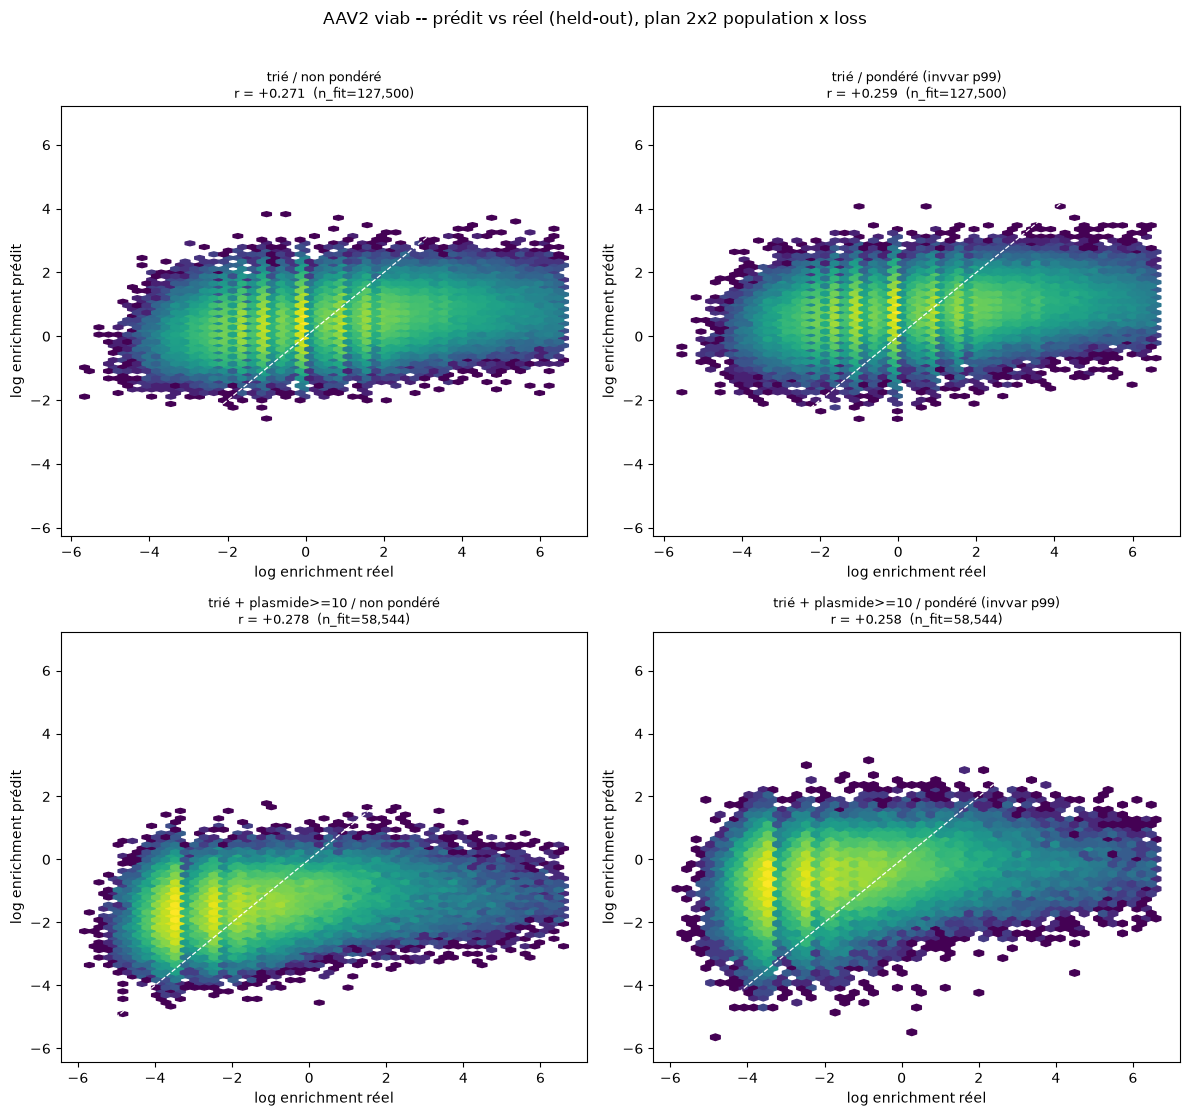

In [7]:
keys = list(results.keys())
fig, axes = plt.subplots(2, 2, figsize=(12, 11))
for ax, key in zip(axes.ravel(), keys):
    res = results[key]
    y, p = res["y_eval"], res["pred_eval"]
    ax.hexbin(y, p, gridsize=50, bins="log", mincnt=1, cmap="viridis")
    lo, hi = min(y.min(), p.min()), max(y.max(), p.max())
    ax.plot([lo, hi], [lo, hi], "w--", lw=0.9)
    ax.set_title(f"{key}\nr = {res['r']:+.3f}  (n_fit={res['n_fit']:,})", fontsize=9)
    ax.set_xlabel("log enrichment réel"); ax.set_ylabel("log enrichment prédit")
fig.suptitle("AAV2 viab -- prédit vs réel (held-out), plan 2x2 population x loss", y=1.01)
fig.tight_layout()
plt.show()


### 6. Recovery top-k% et tableau récapitulatif

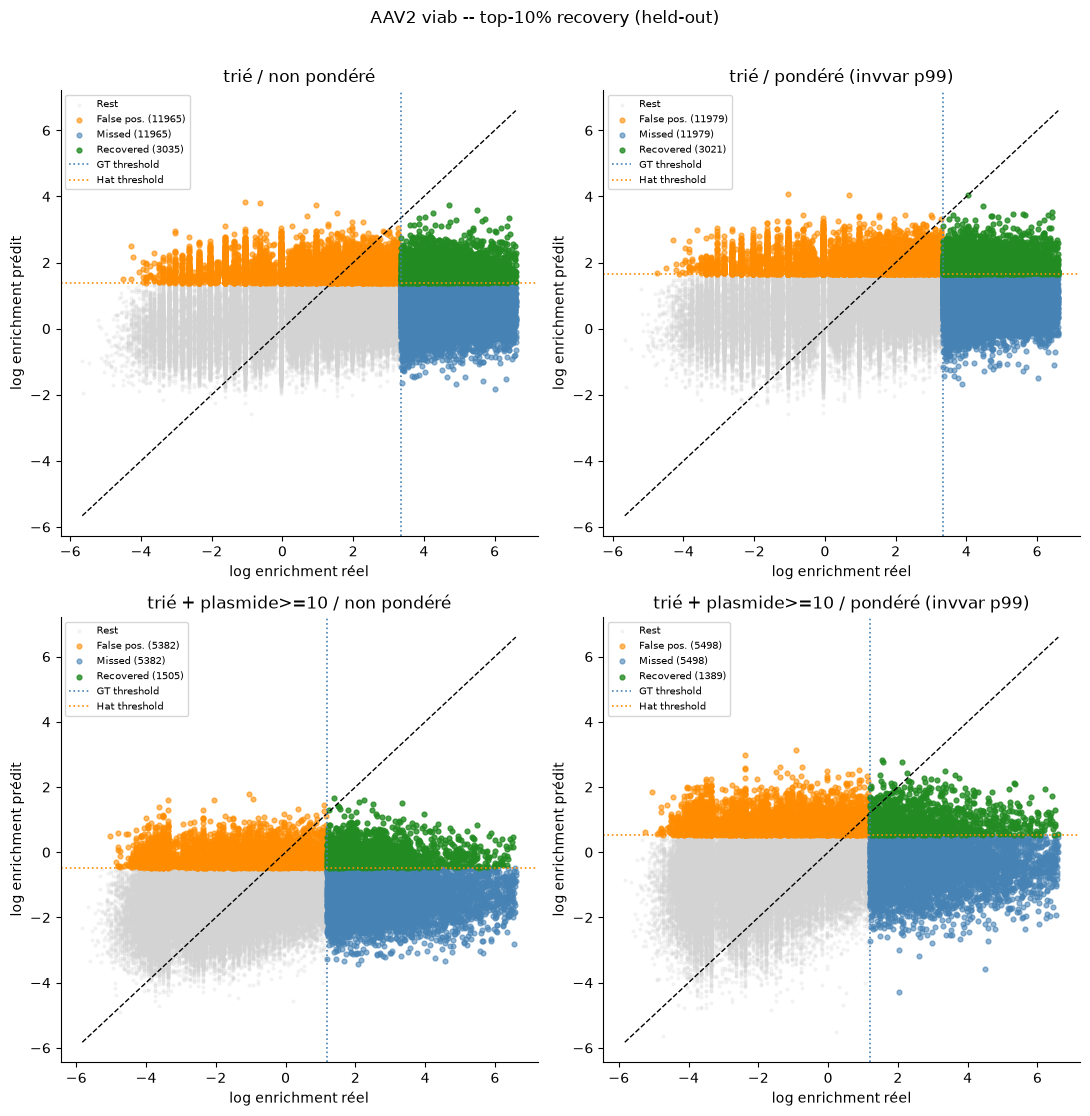

,variante,n_fit,n_eval,Pearson r,top-1%,top-5%,top-10%,top-20%
0,trié / non pondéré,127500,150000,0.271,0.033,0.119,0.202,0.325
1,trié / pondéré (invvar p99),127500,150000,0.259,0.039,0.121,0.201,0.319
2,trié + plasmide>=10 / non pondéré,58544,68876,0.278,0.022,0.118,0.219,0.347
3,trié + plasmide>=10 / pondéré (invvar p99),58544,68876,0.258,0.019,0.110,0.202,0.329


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(11, 11))
for ax, key in zip(axes.ravel(), keys):
    res = results[key]
    plot_topk_recovery(res["y_eval"], res["pred_eval"], k_frac=0.10,
                        xlabel="log enrichment réel", ylabel="log enrichment prédit",
                        title=key, ax=ax)
    ax.legend(fontsize=7)
fig.suptitle("AAV2 viab -- top-10% recovery (held-out)", y=1.01)
fig.tight_layout()
plt.show()

rows = []
for key in keys:
    res = results[key]
    row = {"variante": key, "n_fit": res["n_fit"], "n_eval": res["n_eval"], "Pearson r": round(res["r"], 3)}
    for frac in (0.01, 0.05, 0.10, 0.20):
        row[f"top-{int(frac*100)}%"] = round(precision_at_k(res["y_eval"], res["pred_eval"], k_frac=frac), 3)
    rows.append(row)
summary = pd.DataFrame(rows)
summary


### 7. Delta vs baseline (trié / non pondéré)

In [9]:
base = summary[summary["variante"] == "trié / non pondéré"].iloc[0]
metrics = ["Pearson r", "top-1%", "top-5%", "top-10%", "top-20%"]
delta = summary[summary["variante"] != "trié / non pondéré"][["variante"] + metrics].copy()
for m in metrics:
    delta[m] = (delta[m] - base[m]).round(3)
delta.columns = ["variante"] + [f"Delta {m} (vs trié/non pondéré)" for m in metrics]
delta


,variante,Delta Pearson r (vs trié/non pondéré),Delta top-1% (vs trié/non pondéré),Delta top-5% (vs trié/non pondéré),Delta top-10% (vs trié/non pondéré),Delta top-20% (vs trié/non pondéré)
1,trié / pondéré (invvar p99),-0.012,0.006,0.002,-0.001,-0.006
2,trié + plasmide>=10 / non pondéré,0.007,-0.011,-0.001,0.017,0.022
3,trié + plasmide>=10 / pondéré (invvar p99),-0.013,-0.014,-0.009,0.000,0.004


### 8. Notes

- Les 4 variantes partagent exactement le même split fit/eval et le même split train/val par
  population (seed=0) -- seule la loss d'entraînement (pondérée ou non) ou la population
  (filtrée ou non) diffère, jamais les deux à la fois entre une variante et sa comparaison
  directe.
- Référence Potts (méthode linéaire) sur la même population `trié` : held-out r=+0.266
  (`AAV2_viab_sorting.ipynb` §9). Sur la population top-10k par `compte_plasmide` (différente de
  `trié + plasmide>=10` testé ici -- top-N vs seuil) : Potts CV r=+0.252, ProfileMLP r=+0.274
  (`AAV2_viab_top10k_potts_protocol_mlp.ipynb`).
- Si tu veux pousser plus loin le levier "filtre de profondeur" : `AAV2_viab_noise_ceiling.ipynb`
  §5 donne le plafond théorique de corrélation en fonction du seuil `compte_plasmide` -- comparer
  le `r` obtenu ici à ce plafond, au même seuil, dit si la variante filtrée est déjà proche de
  ce qui est extractible ou s'il reste de la marge.
- Hors périmètre (décidé en session) : loss Poisson/Multinomial, architecture "deep" (déjà testée
  et écartée sur AAV5 `sel_org2`, cf. `CLAUDE.md`).